In [4]:
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import pandas as pd
ds = fetch_california_housing()
#ds is a dictonary


In [ ]:
ds.keys()
#target_name  give name of to be predicted column
#feature_names give name of all the features
#ds.data


dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [ ]:
print(ds.DESCR)

In [12]:
print(ds.feature_names)
print(ds.target_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
['MedHouseVal']


In [16]:
X = pd.DataFrame(ds.data,columns=ds.feature_names)
X.head()
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [17]:
Y = pd.DataFrame(ds.target,columns=ds.target_names)
Y.head()
Y.isnull().sum()

MedHouseVal    0
dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=45)

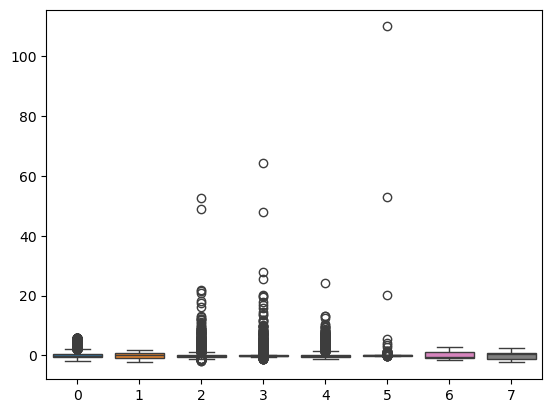

In [25]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)
sns.boxplot(X_train)
plt.show()

In [20]:
from sklearn.linear_model import LinearRegression
l = LinearRegression()
l.fit(X_train,Y_train)
print(l.coef_)
print(l.intercept_)

[[ 0.82417201  0.11737762 -0.27094158  0.31168438 -0.00396759 -0.04416443
  -0.91301824 -0.8862216 ]]
[2.06368851]


In [21]:
Y_pred = l.predict(X_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse = mean_squared_error(Y_pred,Y_test)
mae = mean_absolute_error(Y_pred,Y_test)
r2 = r2_score(Y_pred,Y_test)
print(mse)
print(mae)
print(r2)

0.5248542632112425
0.5319622386699497
0.3367952261174739


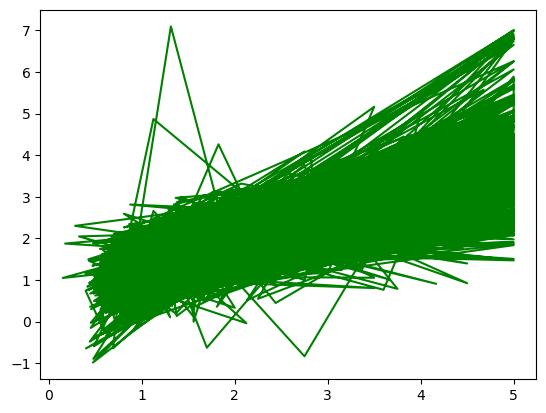

In [22]:
plt.plot(Y_test,Y_pred,'g')
plt.show()

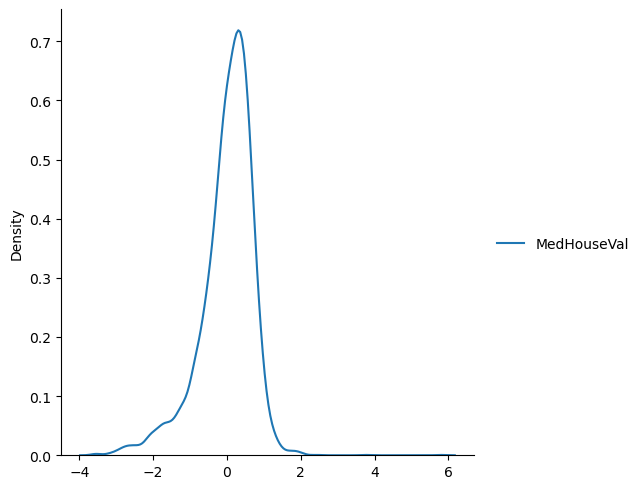

In [23]:
r = Y_pred-Y_test
sns.displot(r,kind='kde')
plt.show()


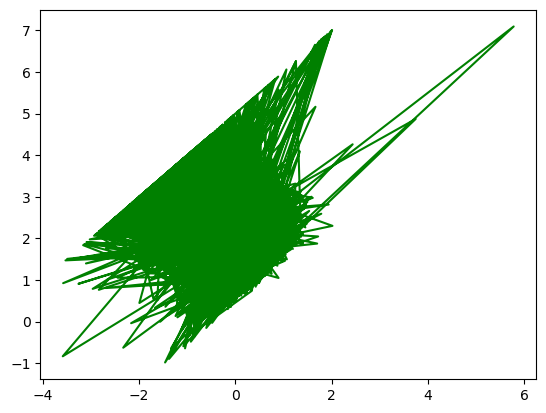

In [24]:
plt.plot(r,Y_pred,'g')
plt.show()

In [ ]:
#Pickling
#pickling is used for serialising and de serializing a python structure . done so it can be saved on disk.
#convert python object to character stream

In [26]:
import pickle 
pickle.dump(l,open('regression.pkl','wb'))

In [ ]:
model = pickle.load(open('regression.pkl','rb'))